Implementation of character level language model.It predicts the next character in the sequence. 

The language model implemented here is Bigram level language model. In this model, we work with 2 characters at a time. 

Flow of this model:
TRAINING DATA
(list of names)
      ->
   TRAINING
(count bigrams → build N → convert to P)
      ->
  TRAINED MODEL
(probability table P)
     ->
   SAMPLING
(generate new names using P)
     ->
   OUTPUT
("emma", "olivia", "aria" ...)

In [1]:
words = open('/kaggle/input/datasets/maitrivaghela/namesdata/names_makemore.txt', 'r').read().splitlines()

In [2]:
import torch
# Creating a 2-d array with 28, 28 dimension. 26 for a-z and 2 more for <S> and <E>
N = torch.zeros((28, 28), dtype=torch.int32)

In [3]:
chars = sorted(list(set(''.join(words))))

# enumerate adds a counter to each item as you loop through it.
# i+1 shifts all character indices by 1, freeing up index 0
sToI = {s:i+1 for i, s in enumerate(chars)} # sToI will be a dictionary 

# '.' represents both start and end of a word, assigned to index 0
# keeps matrix organized with word boundaries in the first row and column
sToI['.'] = 0

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

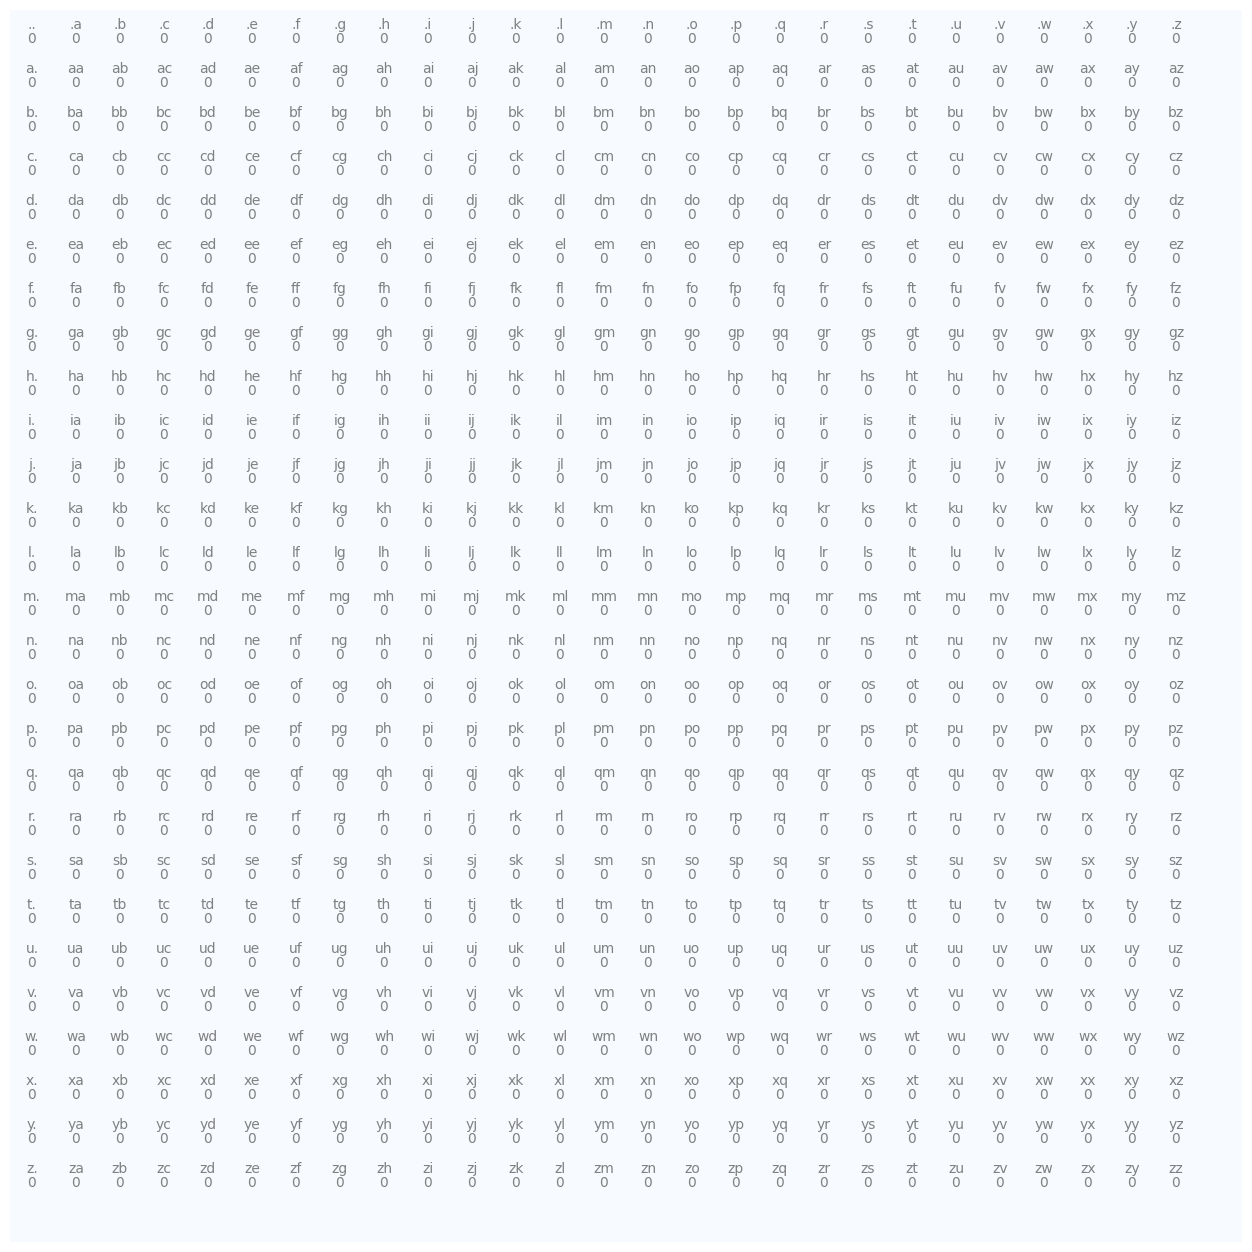

In [4]:
itos = {i:s for s, i in sToI.items()}

# Plot the results
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va = "bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color = 'gray')
plt.axis('off')

In [5]:
# Casting bigram character-level language model into neural network framework

# Creating training set of bigrams (x, y)

xs, ys = [],[]
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = sToI[ch1]
        ix2 = sToI[ch2]
        print(ix1, ix2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

# xs
ys

0 5
5 13
13 13
13 1
1 0


tensor([ 5, 13, 13,  1,  0])

In [6]:
import torch.nn.functional as f
xenc = f.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

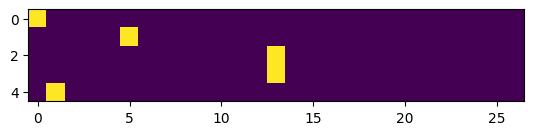

In [7]:
plt.imshow(xenc)

In [8]:
# ----------------- NN Implementation-------------------
# TRAINING (count bigrams → build N → convert to P). TRAINED MODEL (probability table P) 
g = torch.Generator().manual_seed(2147483647)
# Generate random weights
W = torch.randn((27, 27), generator=g)

# input to NN: one-hot encoding
xenc = f.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp() # counts , equivalent to N above
 # probabilities for next character
probs = counts/counts.sum(1, keepdims=True)
# The last 2 lines here are together called a 'softmax'

# Calculate the performance of NN
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())


--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character: 0.

In [9]:
# ----------------------- Optimized NN ------------------------

# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = sToI[ch1]
    ix2 = sToI[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
# Generate random weights
W = torch.randn((27, 27), generator=g, requires_grad=True)

# gradient descent
for k in range(1):
  
  # forward pass
  xenc = f.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  # loss here is avg negative log likelihood
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  # This functionality is provided by pytorch. 
  # It remembers the computational graph of NN
  loss.backward()
  
  # Adjust weights
  W.data += -50 * W.grad


# Sample the NN model
g = torch.Generator().manual_seed(2147483647)
for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = f.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

number of examples:  228146
3.768618583679199
texzmkloglquszipczktxhkmpmzistttwinmlgdukzka.
zr.
rocxtpucjwtsc.
gmtokmxczisqytxugkwpt.
dajkkluydjmscdgu.
